# Zero-DCE++ with Channel Attention (SE-Block) + Trained Denoiser
## Low-Light Image Enhancement — Evaluation Notebook (v8-compatible)

**Novelty:** SE-Block (Channel Attention, configurable placement/activation) + trained noise-reduction head
**Targets:** PSNR > 19 dB | SSIM > 0.65 | LPIPS < 0.30

Updated to match the v8 training notebook:
- Checkpoint is now a dict (`{'model':..., 'denoise_head':...}`), not a bare state dict.
- `DCENetLite`/`SEBlock` now take `se_positions`/`reduction`/`se_activation`/`se_gate` — must match training exactly or the state dict won't load.
- `DenoiseHead` is now applied in the evaluation loop, since it's part of the trained pipeline, not optional post-processing.
- Section 9's color-cast diagnostic (which assumed the old 24-channel, 8-separate-curves architecture) is rewritten for the single shared 3-channel curve used since v7.

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Optional metrics
try:
    import lpips
    LPIPS_AVAILABLE = True
    lpips_model = lpips.LPIPS(net='alex', verbose=False).to(device)
    lpips_model.eval()
    print('LPIPS loaded')
except ImportError:
    LPIPS_AVAILABLE = False
    print('LPIPS not available — install with: pip install lpips')

try:
    import pyiqa
    # pyiqa exposes many IQA metrics via create_metric(metric_name, device=device)
    try:
        niqe_metric = pyiqa.create_metric('niqe', device=device)
        NIQE_AVAILABLE = True
        print('NIQE (pyiqa) loaded')
    except Exception as e:
        NIQE_AVAILABLE = False
        print("pyiqa installed but NIQE model not available via pyiqa.create_metric('niqe'). Try: pip install -U pyiqa or pip install git+https://github.com/chaofengc/IQA-PyTorch.git")
except ImportError:
    NIQE_AVAILABLE = False
    print('pyiqa not installed — install with: pip install pyiqa')


Device: cuda
GPU: NVIDIA GeForce RTX 3060
LPIPS loaded
NIQE (pyiqa) loaded


### Model Definition (must be identical to training, including SE config)

In [2]:
class SEBlock(nn.Module):
    _ACT = {
        'relu':  lambda: nn.ReLU(inplace=True),
        'prelu': lambda: nn.PReLU(),
        'silu':  lambda: nn.SiLU(inplace=True),
        'gelu':  lambda: nn.GELU(),
    }
    _GATE = {
        'sigmoid':     lambda: nn.Sigmoid(),
        'hardsigmoid': lambda: nn.Hardsigmoid(inplace=True),
    }

    def __init__(self, channels, reduction=4, activation='relu', gate='sigmoid'):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            self._ACT[activation](),
            nn.Linear(channels // reduction, channels, bias=False),
            self._GATE[gate](),
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w


class DepthSeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding,
                                    groups=in_channels, bias=True)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=True)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class DCENetLite(nn.Module):
    """Must match the training notebook's DCENetLite exactly -- same se_positions,
    reduction, se_activation, se_gate as whatever produced CHECKPOINT."""
    def __init__(self, filters=32, use_attention=True, se_positions=(3,),
                 reduction=4, se_activation='relu', se_gate='sigmoid', iterations=8):
        super().__init__()
        self.use_attention = use_attention
        self.se_positions  = set(se_positions) if use_attention else set()
        self.iterations    = iterations

        self.conv1 = DepthSeparableConv2d(3,          filters)
        self.conv2 = DepthSeparableConv2d(filters,    filters)
        self.conv3 = DepthSeparableConv2d(filters,    filters)
        self.conv4 = DepthSeparableConv2d(filters,    filters)
        self.conv5 = DepthSeparableConv2d(filters*2,  filters)
        self.conv6 = DepthSeparableConv2d(filters*2,  filters)
        self.conv7 = DepthSeparableConv2d(filters*2,  3)
        self.relu  = nn.ReLU(inplace=True)

        if use_attention:
            self.se_blocks = nn.ModuleDict({
                str(pos): SEBlock(filters, reduction=reduction,
                                   activation=se_activation, gate=se_gate)
                for pos in self.se_positions
            })

    def _se(self, feat, pos):
        if pos in self.se_positions:
            return self.se_blocks[str(pos)](feat)
        return feat

    def forward(self, x):
        x1 = self._se(self.relu(self.conv1(x)),  1)
        x2 = self._se(self.relu(self.conv2(x1)), 2)
        x3 = self._se(self.relu(self.conv3(x2)), 3)
        x4 = self._se(self.relu(self.conv4(x3)), 4)
        x5 = self.relu(self.conv5(torch.cat([x3, x4], 1)))
        x6 = self.relu(self.conv6(torch.cat([x2, x5], 1)))
        a_map = torch.tanh(self.conv7(torch.cat([x1, x6], 1)))  # [B, 3, H, W]
        return a_map


class DenoiseHead(nn.Module):
    """Must match training exactly: depthwise-separable residual, x0.1 scale."""
    def __init__(self, channels=16):
        super().__init__()
        self.conv1 = DepthSeparableConv2d(3, channels)
        self.conv2 = DepthSeparableConv2d(channels, 3)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, enhanced):
        residual = self.relu(self.conv1(enhanced))
        residual = torch.tanh(self.conv2(residual)) * 0.1
        return torch.clamp(enhanced + residual, 0, 1)


def enhance_image_with_curves(x, a_map, iterations=8):
    """LE(x;a) = x + a*(x^2 - x), same curve reused across all 8 iterations"""
    enhanced = x
    for _ in range(iterations):
        enhanced = enhanced + a_map * (enhanced.pow(2) - enhanced)
    return torch.clamp(enhanced, 0, 1)

print('Model, SE-Block, DenoiseHead and curve function defined')

Model, SE-Block, DenoiseHead and curve function defined


### Dataset — Full Original Resolution (no forced resize)

In [3]:
class LOLDataset(Dataset):
    """
    Evaluation dataset: loads images at ORIGINAL resolution.
    No resizing or cropping — metrics must be on native pixels.
    """
    def __init__(self, image_pairs):
        self.image_pairs = image_pairs

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):
        pair = self.image_pairs[idx]
        low_img    = Image.open(pair['low']).convert('RGB')
        normal_img = Image.open(pair['normal']).convert('RGB')
        low_tensor    = transforms.ToTensor()(low_img)
        normal_tensor = transforms.ToTensor()(normal_img)
        return {'low': low_tensor, 'normal': normal_tensor,
                'filename': pair['filename']}

def load_image_pairs(data_path):
    """
    FIX: LOL-v2 uses numeric filenames (1.png, 2.png...).
    .replace('low','normal') silently fails — pair by sorted order instead.
    """
    low_path    = data_path / 'Low'
    normal_path = data_path / 'Normal'
    low_images    = sorted([f for f in os.listdir(low_path)
                            if f.endswith(('.jpg', '.png'))])
    normal_images = sorted([f for f in os.listdir(normal_path)
                            if f.endswith(('.jpg', '.png'))])
    assert len(low_images) == len(normal_images), (
        f'Mismatch: {len(low_images)} low vs {len(normal_images)} normal'
    )
    pairs = []
    for low_f, normal_f in zip(low_images, normal_images):
        pairs.append({
            'low':      str(low_path    / low_f),
            'normal':   str(normal_path / normal_f),
            'filename': low_f
        })
    return pairs

print('Dataset helpers defined')


Dataset helpers defined


### Load Model and Test Data

In [4]:
CHECKPOINT = 'best_zerodce_pp_seblock.pth'  # update filename as needed
BASE_PATH  = Path('LOL-v2')

# Must match whatever config produced CHECKPOINT -- change these together with
# the training notebook's model constructor if you ran an ablation variant.
SE_POSITIONS   = (3,)
REDUCTION      = 4
SE_ACTIVATION  = 'relu'
SE_GATE        = 'sigmoid'
USE_DENOISER   = True   # set False to evaluate curve-enhancement alone, without the trained denoiser

ckpt = torch.load(CHECKPOINT, map_location=device)

model = DCENetLite(use_attention=True, se_positions=SE_POSITIONS, reduction=REDUCTION,
                    se_activation=SE_ACTIVATION, se_gate=SE_GATE).to(device)
model.load_state_dict(ckpt['model'])
model.eval()

denoise_head = None
if USE_DENOISER:
    denoise_head = DenoiseHead().to(device)
    denoise_head.load_state_dict(ckpt['denoise_head'])
    denoise_head.eval()

print(f'Model loaded from: {CHECKPOINT}')
n_params = sum(p.numel() for p in model.parameters())
if denoise_head is not None:
    n_params += sum(p.numel() for p in denoise_head.parameters())
print(f'Parameters (model{"+denoiser" if denoise_head is not None else ""}): {n_params:,}')

test_pairs  = load_image_pairs(BASE_PATH / 'Real_captured' / 'Test')
# batch_size=1 for full-resolution images (variable sizes won't stack otherwise)
test_dataset = LOLDataset(test_pairs)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)
print(f'Test set: {len(test_pairs)} images')

Model loaded from: best_zerodce_pp_seblock.pth
Parameters (model+denoiser): 11,378
Test set: 100 images


### Evaluation Loop

In [5]:
test_metrics = {'psnr': [], 'ssim': [], 'lpips': [], 'niqe': []}
enhanced_images, low_images, normal_images, filenames = [], [], [], []

with torch.no_grad():
    pbar = tqdm(test_loader, desc='Evaluating')
    for batch in pbar:
        low_imgs    = batch['low'].to(device)
        normal_imgs = batch['normal'].to(device)

        alpha    = model(low_imgs)
        enhanced = enhance_image_with_curves(low_imgs, alpha)
        if denoise_head is not None:
            enhanced = denoise_head(enhanced)

        # -- Safety clamp: guarantee [0,1], no NaN or Inf --
        enhanced = torch.clamp(enhanced, 0.0, 1.0)
        if torch.isnan(enhanced).any() or torch.isinf(enhanced).any():
            print(f"  WARNING: NaN/Inf in enhanced output for {batch['filename'][0]} -- skipping")
            continue

        # -- numpy conversion (float32, no uint8) --
        enh_np = enhanced.squeeze(0).cpu().permute(1, 2, 0).numpy()
        ref_np = normal_imgs.squeeze(0).cpu().permute(1, 2, 0).numpy()
        low_np = low_imgs.squeeze(0).cpu().permute(1, 2, 0).numpy()

        # -- PSNR / SSIM (always safe) --
        psnr_val = psnr_metric(ref_np, enh_np, data_range=1.0)
        ssim_val = ssim_metric(ref_np, enh_np, channel_axis=2, data_range=1.0)
        test_metrics['psnr'].append(psnr_val)
        test_metrics['ssim'].append(ssim_val)

        # -- LPIPS (guard against SVD failure on flat regions) --
        if LPIPS_AVAILABLE:
            try:
                enh_t = (enhanced * 2 - 1).clamp(-1, 1)
                ref_t = (normal_imgs * 2 - 1).clamp(-1, 1)
                enh_t = enh_t + torch.randn_like(enh_t) * 1e-6
                lp = lpips_model(enh_t, ref_t).item()
                test_metrics['lpips'].append(lp)
            except Exception as e:
                print(f"  LPIPS skipped for {batch['filename'][0]}: {type(e).__name__}")
                test_metrics['lpips'].append(float('nan'))

        # -- NIQE (guard against matrix errors too) --
        if NIQE_AVAILABLE:
            try:
                niqe_score = niqe_metric(enhanced)
                niqe_val = niqe_score.item() if hasattr(niqe_score, 'item') else float(niqe_score)
                test_metrics['niqe'].append(niqe_val)
            except Exception as e:
                print(f"  NIQE skipped for {batch['filename'][0]}: {type(e).__name__}")
                test_metrics['niqe'].append(float('nan'))

        enhanced_images.append(enh_np)
        low_images.append(low_np)
        normal_images.append(ref_np)
        filenames.append(batch['filename'][0])

        pbar.set_postfix({'PSNR': f'{psnr_val:.2f}', 'SSIM': f'{ssim_val:.3f}'})

print('Evaluation complete!')

Evaluating: 100%|██████████| 100/100 [00:20<00:00,  4.85it/s, PSNR=17.14, SSIM=0.534]

Evaluation complete!


### Results Summary

In [6]:
import numpy as np

# ── Build metrics_info from whatever was collected ─────────────────────────
metrics_info = [
    ('PSNR (dB)', test_metrics['psnr'],  '> 19.00', 19.0, True),
    ('SSIM',      test_metrics['ssim'],  '> 0.65',  0.65, True),
]
if LPIPS_AVAILABLE and test_metrics['lpips']:
    metrics_info.append(('LPIPS', test_metrics['lpips'], '< 0.30', 0.30, False))
if NIQE_AVAILABLE and test_metrics['niqe']:
    metrics_info.append(('NIQE',  test_metrics['niqe'],  '< 3.80', 3.80, False))

# ── Print summary ──────────────────────────────────────────────────────────
print('\n' + '='*55)
print('FINAL EVALUATION RESULTS')
print('='*55)

for name, vals, target, thresh, higher_better in metrics_info:
    clean   = [v for v in vals if not np.isnan(v)]
    if not clean:
        print(f'\n{name}: all values were NaN — skipped')
        continue
    mean_v  = np.mean(clean)
    std_v   = np.std(clean)
    skipped = len(vals) - len(clean)
    passed  = mean_v > thresh if higher_better else mean_v < thresh
    status  = 'PASS' if passed else 'FAIL'
    print(f'\n{name}:')
    print(f'  Mean:    {mean_v:.4f}')
    print(f'  Std:     {std_v:.4f}')
    print(f'  Min:     {np.min(clean):.4f}')
    print(f'  Max:     {np.max(clean):.4f}')
    if skipped:
        print(f'  Skipped: {skipped} image(s) — NaN (SVD/metric error)')
    print(f'  Target:  {target}  →  [{status}]')

print('\n' + '='*55)


FINAL EVALUATION RESULTS

PSNR (dB):
  Mean:    19.7988
  Std:     4.4620
  Min:     11.9937
  Max:     27.9159
  Target:  > 19.00  →  [PASS]

SSIM:
  Mean:    0.6546
  Std:     0.0989
  Min:     0.4412
  Max:     0.8374
  Target:  > 0.65  →  [PASS]

LPIPS:
  Mean:    0.2767
  Std:     0.1235
  Min:     0.0969
  Max:     0.5705
  Target:  < 0.30  →  [PASS]

NIQE:
  Mean:    8.0216
  Std:     1.3798
  Min:     4.7560
  Max:     12.7667
  Target:  < 3.80  →  [FAIL]



### Metrics Distribution

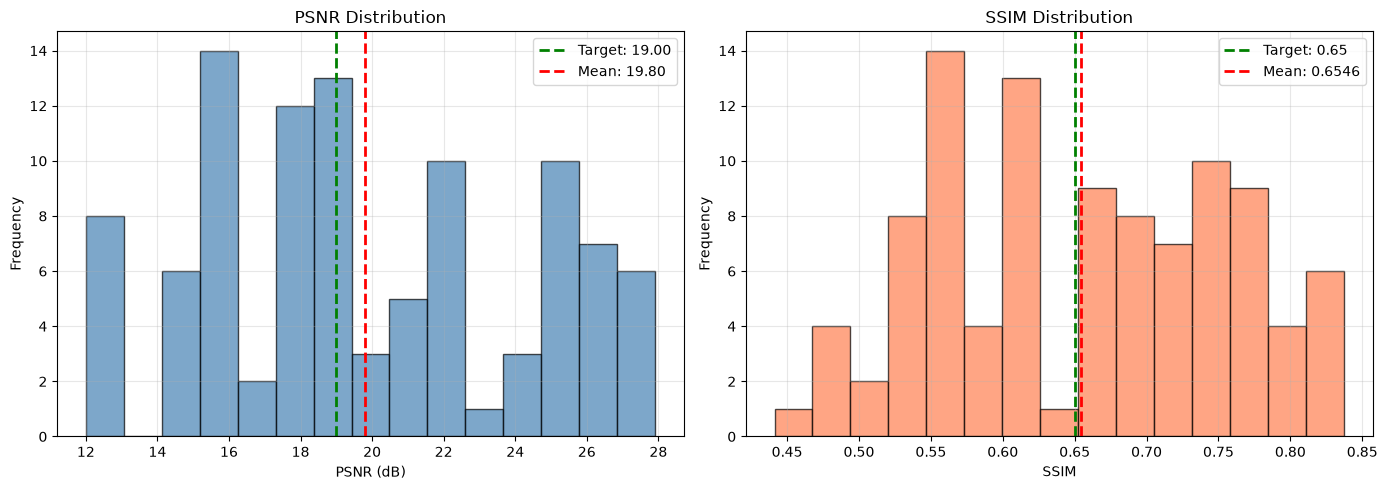

Saved: metrics_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(test_metrics['psnr'], bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(19, color='green', linestyle='--', linewidth=2, label='Target: 19.00')
axes[0].axvline(np.mean(test_metrics['psnr']), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {np.mean(test_metrics['psnr']):.2f}")
axes[0].set_xlabel('PSNR (dB)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('PSNR Distribution'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(test_metrics['ssim'], bins=15, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0.65, color='green', linestyle='--', linewidth=2, label='Target: 0.65')
axes[1].axvline(np.mean(test_metrics['ssim']), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {np.mean(test_metrics['ssim']):.4f}")
axes[1].set_xlabel('SSIM'); axes[1].set_ylabel('Frequency')
axes[1].set_title('SSIM Distribution'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_distribution.png', dpi=150)
plt.show()
print('Saved: metrics_distribution.png')


### Visual Comparison: Low-Light | Enhanced | Ground Truth

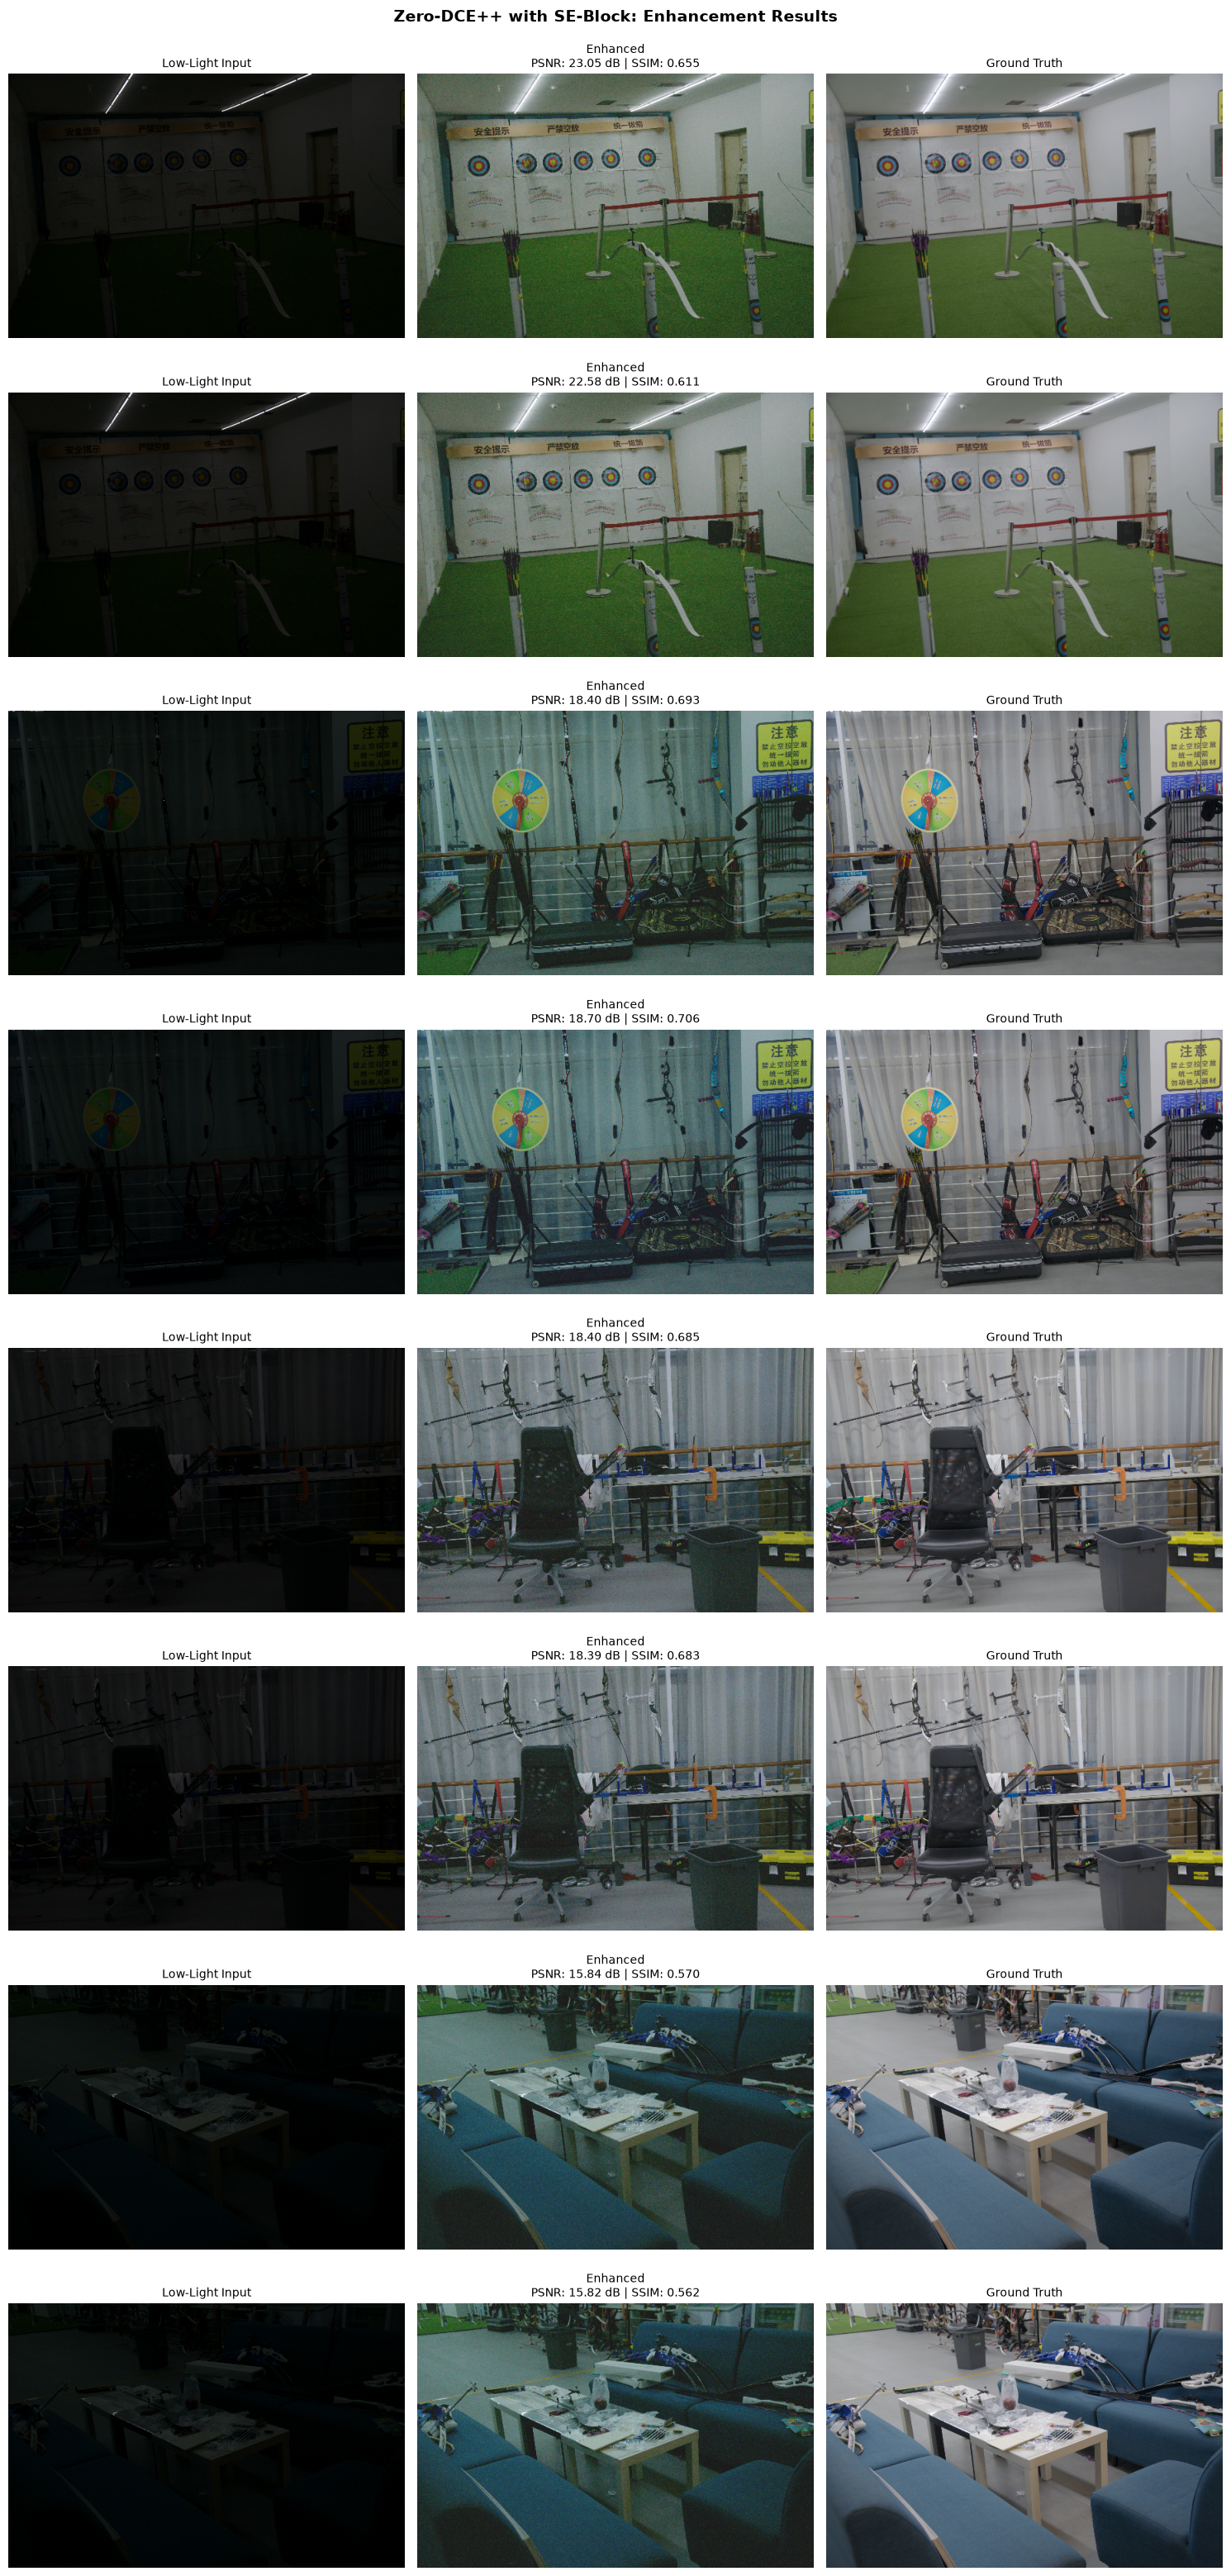

Saved: evaluation_results.png


In [8]:
num_show = min(8, len(enhanced_images))
fig, axes = plt.subplots(num_show, 3, figsize=(15, 4*num_show))

for idx in range(num_show):
    axes[idx, 0].imshow(np.clip(low_images[idx], 0, 1))
    axes[idx, 0].set_title('Low-Light Input', fontsize=10)
    axes[idx, 0].axis('off')

    axes[idx, 1].imshow(np.clip(enhanced_images[idx], 0, 1))
    p = test_metrics['psnr'][idx]
    s = test_metrics['ssim'][idx]
    axes[idx, 1].set_title(f'Enhanced\nPSNR: {p:.2f} dB | SSIM: {s:.3f}', fontsize=10)
    axes[idx, 1].axis('off')

    axes[idx, 2].imshow(np.clip(normal_images[idx], 0, 1))
    axes[idx, 2].set_title('Ground Truth', fontsize=10)
    axes[idx, 2].axis('off')

plt.suptitle('Zero-DCE++ with SE-Block: Enhancement Results\n\n', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_results_noseblock.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: evaluation_results.png')


### Per-Image Results Table

In [9]:
print(f"{'Filename':<25} {'PSNR':>8} {'SSIM':>8}" +
      (f" {'LPIPS':>8}" if LPIPS_AVAILABLE and test_metrics['lpips'] else '') + '\n' +
      '-'*55)
for i, fname in enumerate(filenames):
    lp_str = f"{test_metrics['lpips'][i]:>8.4f}" if LPIPS_AVAILABLE and test_metrics['lpips'] else ''
    print(f"{fname:<25} {test_metrics['psnr'][i]:>8.2f} {test_metrics['ssim'][i]:>8.4f}{lp_str}")
print('-'*55)
print(f"{'MEAN':<25} {np.mean(test_metrics['psnr']):>8.2f} {np.mean(test_metrics['ssim']):>8.4f}" +
      (f" {np.mean(test_metrics['lpips']):>8.4f}" if LPIPS_AVAILABLE and test_metrics['lpips'] else ''))


Filename                      PSNR     SSIM    LPIPS
-------------------------------------------------------
low00690.png                 23.05   0.6546  0.2099
low00691.png                 22.58   0.6106  0.2144
low00692.png                 18.40   0.6931  0.2306
low00693.png                 18.70   0.7063  0.2231
low00694.png                 18.40   0.6847  0.2356
low00695.png                 18.39   0.6830  0.2362
low00696.png                 15.84   0.5700  0.3592
low00697.png                 15.82   0.5625  0.3595
low00698.png                 15.80   0.5006  0.5066
low00699.png                 15.80   0.4826  0.5158
low00700.png                 18.69   0.6107  0.2394
low00701.png                 18.79   0.6198  0.2335
low00702.png                 12.57   0.5383  0.4491
low00703.png                 12.55   0.5375  0.4486
low00704.png                 12.47   0.5342  0.4488
low00705.png                 12.37   0.4857  0.5607
low00706.png                 12.48   0.4922  0.5705
low0070

### 9. Per-channel curve strength (rewritten for the single shared 3-channel curve)

The original version of this cell assumed the pre-v7 architecture, where `a_map` held
8 separate iteration-specific curves packed into 24 channels (summed across iterations
to see cumulative push per channel). Since v7, `a_map` is a single 3-channel curve
reused identically across all 8 iterations -- there's nothing to sum across iterations
anymore, since it's the same 3 numbers applied 8 times. This was originally written to
diagnose the green color-cast bug in the abandoned v5/v6 DPED-hybrid direction; keep it
only if you still want to sanity-check per-channel curve balance under the current
pure zero-reference setup.

In [ ]:
idx = 0  # change this to inspect a different test image (0..len(filenames)-1)

sample_low  = low_images[idx]
sample_enh  = enhanced_images[idx]
sample_ref  = normal_images[idx]
sample_name = filenames[idx]

low_tensor = torch.from_numpy(sample_low).permute(2, 0, 1).unsqueeze(0).float().to(device)
with torch.no_grad():
    alpha = model(low_tensor)  # [1, 3, H, W] -- single shared curve (same 8 iterations)

channel_names = ['R', 'G', 'B']
alpha_per_channel = [alpha[0, c].cpu().numpy() for c in range(3)]

# -- Spatial heatmaps: where is each channel's curve pushing hardest? --
vmax = max(a.max() for a in alpha_per_channel)
vmin = min(a.min() for a in alpha_per_channel)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for c, name in enumerate(channel_names):
    im = axes[c].imshow(alpha_per_channel[c], cmap='RdBu_r', vmin=vmin, vmax=vmax)
    axes[c].set_title(f'{name} channel -- curve strength (single shared curve)')
    axes[c].axis('off')
fig.colorbar(im, ax=axes, shrink=0.7, label='alpha')
plt.suptitle(f'Per-channel curve strength -- {sample_name}')
plt.savefig('alpha_channel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Mean channel values: does the enhanced image drift further from GT than the input did? --
print(f"{'Channel':<10}{'Low input':>12}{'Enhanced':>12}{'Ground truth':>14}")
for c, name in enumerate(channel_names):
    print(f"{name:<10}{sample_low[...,c].mean():>12.4f}{sample_enh[...,c].mean():>12.4f}{sample_ref[...,c].mean():>14.4f}")

print()
print('Mean alpha per channel (higher = that channel\'s curve pushed harder):')
for c, name in enumerate(channel_names):
    print(f'  {name}: {alpha_per_channel[c].mean():.4f}')